# 병해충 이미지 분석 모델 구현 실습 (답안)

AI Hub 「국내 재배 아열대·열대 병해충 데이터」 Sample로
**Hugging Face ViT** 백본 멀티태스크 모델(작물·부위·병해충·bbox)을 학습합니다.

- **환경**: Google Colab(GPU) / 로컬 GPU 모두 지원
- **백본**: `google/vit-base-patch16-224` (`transformers.ViTModel`)
- **데이터 출처**: CC-BY-SA-4.0 (제주특별자치도 컨소시엄)


## 문제 1. 패키지 설치, 한글 폰트, GPU 확인

In [1]:
%pip install -q "transformers>=4.40.0" seaborn scikit-learn tqdm pillow

In [2]:
import os
import json
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False


def setup_korean_font():
    """Colab/로컬에서 한글 폰트를 설정한다."""
    plt.rcParams["axes.unicode_minus"] = False
    candidates = [
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
        "C:/Windows/Fonts/malgun.ttf",
        "C:/Windows/Fonts/NanumGothic.ttf",
        "/System/Library/Fonts/AppleGothic.ttf",
        "/Library/Fonts/AppleGothic.ttf",
    ]
    names = ["NanumGothic", "Malgun Gothic", "AppleGothic", "NanumBarunGothic"]

    if IN_COLAB:
        import subprocess
        subprocess.run(
            ["apt-get", "-qq", "-y", "install", "fonts-nanum"],
            check=False,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    for fp in candidates:
        if os.path.isfile(fp):
            try:
                fm.fontManager.addfont(fp)
            except Exception:
                pass
            prop = fm.FontProperties(fname=fp)
            family = prop.get_name()
            plt.rc("font", family=family)
            print(f"Korean font: {family}")
            return family

    available = {f.name for f in fm.fontManager.ttflist}
    for name in names:
        if name in available:
            plt.rc("font", family=name)
            print(f"Korean font: {name}")
            return name

    warnings.warn("한글 폰트를 찾지 못했습니다. 그래프 한글이 깨질 수 있습니다.")
    print("Korean font: (not found)")
    return None


setup_korean_font()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_cuda = device.type == "cuda"

if use_cuda:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")

gpu_name = torch.cuda.get_device_name(0) if use_cuda else "N/A"
vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3) if use_cuda else 0.0

print(f"Using device: {device}")
print(f"Colab: {IN_COLAB}")
print(f"GPU: {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")


Korean font: NanumGothic
Using device: cuda
Colab: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB


## 문제 2. 데이터 zip 준비 및 압축 해제

In [3]:
MOUNT_DRIVE = False
ZIP_PATH = ""
EXTRACT_DIR = "/content/pest-data" if IN_COLAB else "./pest-data"

if MOUNT_DRIVE:
    if not IN_COLAB:
        raise RuntimeError("MOUNT_DRIVE=True 는 Colab에서만 사용할 수 있습니다.")
    drive.mount("/content/drive")


def _has_src_lab(path: Path):
    if not path.exists() or not path.is_dir():
        return None
    names = {c.name for c in path.iterdir() if c.is_dir()}
    src = next((n for n in names if n.startswith("01") and "원천" in n), None)
    lab = next((n for n in names if n.startswith("02") and "라벨" in n), None)
    if src and lab:
        return path / src, path / lab
    return None


def find_dataset_root(extract_dir, silent=False):
    root = Path(extract_dir)
    if root.exists():
        hit = _has_src_lab(root)
        if hit:
            return str(root.resolve())
        for depth in range(1, 4):
            pattern = "/".join(["*"] * depth)
            for p in root.glob(pattern):
                if p.is_dir() and _has_src_lab(p):
                    return str(p.resolve())

    if not IN_COLAB:
        cwd = Path.cwd()
        if _has_src_lab(cwd):
            return str(cwd.resolve())
        for p in cwd.iterdir():
            if p.is_dir() and _has_src_lab(p):
                return str(p.resolve())

    if not silent:
        raise FileNotFoundError("01.원천데이터 / 02.라벨링데이터 폴더를 찾지 못했습니다.")
    return None


def find_zip_file(explicit_path=""):
    if explicit_path and os.path.isfile(explicit_path):
        return os.path.abspath(explicit_path)

    search_dirs = []
    if IN_COLAB:
        search_dirs.extend(["/content", "/content/drive/MyDrive"])
    else:
        search_dirs.extend([".", str(Path.cwd().resolve())])

    keywords = ["병해충", "아열대", "열대", "Sample", "국내"]
    found = []
    for d in search_dirs:
        p = Path(d)
        if not p.exists():
            continue
        patterns = ["*.zip", "**/*.zip"] if "MyDrive" in str(p) else ["*.zip"]
        for pat in patterns:
            for z in p.glob(pat):
                if z.is_file():
                    found.append(z)

    uniq, seen = [], set()
    for z in found:
        key = str(z.resolve())
        if key not in seen:
            seen.add(key)
            uniq.append(z)

    if not uniq:
        return None

    def score(z: Path):
        name = z.name
        s = sum(1 for kw in keywords if kw.lower() in name.lower() or kw in name)
        if "Sample" in name or "sample" in name.lower():
            s += 10
        return s

    uniq = sorted(uniq, key=lambda z: (-score(z), z.name))
    return str(uniq[0].resolve())


def unzip_dataset(zip_path, extract_dir):
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    existing = find_dataset_root(str(extract_dir), silent=True)
    if existing is not None:
        print(f"이미 압축 해제된 데이터 발견: {existing}")
        return str(existing)
    print(f"압축 해제 중 → {extract_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    return str(extract_dir)


zip_path = find_zip_file(ZIP_PATH)
BASE_DIR = None

if zip_path is None:
    BASE_DIR = find_dataset_root(EXTRACT_DIR, silent=True)
    if BASE_DIR is None and not IN_COLAB:
        BASE_DIR = find_dataset_root(".", silent=True)
    if BASE_DIR is None:
        if IN_COLAB:
            print("zip을 찾지 못했습니다. 파일을 업로드하세요.")
            uploaded = files.upload()
            for name in uploaded:
                if name.lower().endswith(".zip"):
                    zip_path = os.path.abspath(name)
                    break
            if zip_path is None:
                raise FileNotFoundError("업로드된 zip이 없습니다.")
        else:
            raise FileNotFoundError(
                "zip 또는 이미 압축 해제된 데이터를 찾지 못했습니다. "
                "ZIP_PATH를 지정하거나 실습 폴더에서 실행하세요."
            )

if zip_path is not None:
    size_mb = os.path.getsize(zip_path) / (1024 * 1024)
    unzip_dataset(zip_path, EXTRACT_DIR)
    BASE_DIR = find_dataset_root(EXTRACT_DIR)
    print(f"사용할 zip: {zip_path}")
    print(f"파일 크기: {size_mb:.1f} MB")
else:
    print("사용할 zip: (이미 압축 해제된 데이터 사용)")
    print("파일 크기: - MB")

BASE_DIR = Path(BASE_DIR)
SRC_DIR, LAB_DIR = _has_src_lab(BASE_DIR)
print(f"데이터 루트: {BASE_DIR}")
print(f"원천데이터: {SRC_DIR}")
print(f"라벨링데이터: {LAB_DIR}")
print(f"구성: {[p.name for p in BASE_DIR.iterdir()]}")


압축 해제 중 → /content/pest-data
사용할 zip: /content/국내 재배 아열대·열대 병해충 데이터-Samle.zip
파일 크기: 982.1 MB
데이터 루트: /content/pest-data/Sample
원천데이터: /content/pest-data/Sample/01.원천데이터
라벨링데이터: /content/pest-data/Sample/02.라벨링데이터
구성: ['01.원천데이터', '02.라벨링데이터']


## 문제 3. JSON 라벨 파싱 및 메타데이터 구축

In [4]:
def _to_float(v):
    try:
        s = str(v).strip()
        if s == "":
            return np.nan
        return float(s)
    except Exception:
        return np.nan


def _parse_bboxes(bbox_info):
    boxes = []
    for b in bbox_info or []:
        try:
            x = int(float(b["bbox_xcrdnt"]))
            y = int(float(b["bbox_ycrdnt"]))
            w = int(float(b["bbox_width"]))
            h = int(float(b["bbox_height"]))
            boxes.append({"x": x, "y": y, "w": w, "h": h})
        except Exception:
            continue
    return boxes


def build_metadata(src_dir, lab_dir) -> pd.DataFrame:
    src_dir = Path(src_dir)
    lab_dir = Path(lab_dir)

    img_index = {}
    for p in src_dir.rglob("*"):
        if p.suffix.lower() in {".jpg", ".jpeg", ".png"}:
            img_index[p.name] = str(p.resolve())
            img_index[p.stem] = str(p.resolve())

    rows = []
    skipped = 0
    json_files = list(lab_dir.rglob("*.JSON")) + list(lab_dir.rglob("*.json"))
    seen, unique_jsons = set(), []
    for j in json_files:
        k = str(j.resolve()).lower()
        if k not in seen:
            seen.add(k)
            unique_jsons.append(j)

    for jpath in tqdm(unique_jsons, desc="JSON parsing"):
        with open(jpath, encoding="utf-8") as f:
            obj = json.load(f)
        images = obj.get("images", {})
        ann = obj.get("annotations", {})
        env = obj.get("environments", {})

        image_file_nm = images.get("image_file_nm", "")
        image_id = images.get("image_file_id", Path(image_file_nm).stem)
        path = (
            img_index.get(image_file_nm)
            or img_index.get(Path(image_file_nm).stem)
            or img_index.get(image_id)
        )
        if path is None:
            skipped += 1
            continue

        boxes = _parse_bboxes(ann.get("bbox_info"))
        main = max(boxes, key=lambda b: b["w"] * b["h"]) if boxes else {"x": 0, "y": 0, "w": 0, "h": 0}

        rows.append({
            "image_id": image_id,
            "image_file_nm": image_file_nm,
            "path": path,
            "json_path": str(jpath.resolve()),
            "crop": ann.get("object_class_lclas_nm"),
            "crop_code": ann.get("object_class_lclas_code"),
            "part": ann.get("object_class_mlsfc_nm"),
            "part_code": ann.get("object_class_mlsfc_code"),
            "disease": ann.get("object_class_sclas_nm"),
            "disease_code": ann.get("object_class_sclas_code"),
            "n_bbox": len(boxes),
            "bbox_x": main["x"],
            "bbox_y": main["y"],
            "bbox_w": main["w"],
            "bbox_h": main["h"],
            "bboxes": boxes,
            "region_nm": images.get("region_nm", ""),
            "temp": _to_float(env.get("temp", "")),
            "hum": _to_float(env.get("hum", "")),
            "soil_temp": _to_float(env.get("soil_temp", "")),
        })

    out = pd.DataFrame(rows)
    print(f"data size: {len(out)}")
    print(f"이미지 매칭 실패: {skipped}")
    print(f"작물 수: {out['crop'].nunique()}")
    print(f"부위 수: {out['part'].nunique()}")
    print(f"병해충 수: {out['disease'].nunique()}")
    return out


df = build_metadata(SRC_DIR, LAB_DIR)
display(df.head())
df.info()
print("작물 클래스:")
print(df["crop"].value_counts())
print("부위 클래스:")
print(df["part"].value_counts())
print("병해충 클래스:")
print(df["disease"].value_counts())


JSON parsing:   0%|          | 0/520 [00:00<?, ?it/s]

data size: 520
이미지 매칭 실패: 0
작물 수: 8
부위 수: 3
병해충 수: 18


,image_id,image_file_nm,path,json_path,crop,crop_code,part,part_code,disease,disease_code,n_bbox,bbox_x,bbox_y,bbox_w,bbox_h,bboxes,region_nm,temp,hum,soil_temp
0,HF001_01_999_00059,HF001_01_999_00059.JPG,/content/pest-data/Sample/01.원천데이터/001_애플망고/01...,/content/pest-data/Sample/02.라벨링데이터/001_애플망고/0...,애플망고,001,잎,01,정상,999,1,830,65,357,1907,"[{'x': 830, 'y': 65, 'w': 357, 'h': 1907}]","제주특별자치도, 전라남도",27.9,79.0,26.4
1,HF001_01_999_00084,HF001_01_999_00084.JPG,/content/pest-data/Sample/01.원천데이터/001_애플망고/01...,/content/pest-data/Sample/02.라벨링데이터/001_애플망고/0...,애플망고,001,잎,01,정상,999,1,737,168,343,1348,"[{'x': 737, 'y': 168, 'w': 343, 'h': 1348}]","제주특별자치도, 전라남도",30.9,58.0,26.7
2,HF001_01_999_00012,HF001_01_999_00012.JPG,/content/pest-data/Sample/01.원천데이터/001_애플망고/01...,/content/pest-data/Sample/02.라벨링데이터/001_애플망고/0...,애플망고,001,잎,01,정상,999,1,807,249,548,1733,"[{'x': 807, 'y': 249, 'w': 548, 'h': 1733}]","제주특별자치도, 전라남도",26.7,80.5,28.2
3,HF001_01_999_00134,HF001_01_999_00134.JPG,/content/pest-data/Sample/01.원천데이터/001_애플망고/01...,/content/pest-data/Sample/02.라벨링데이터/001_애플망고/0...,애플망고,001,잎,01,정상,999,1,113,143,694,576,"[{'x': 113, 'y': 143, 'w': 694, 'h': 576}]","제주특별자치도, 전라남도",22.2,96.0,25.8
4,HF001_01_999_00074,HF001_01_999_00074.JPG,/content/pest-data/Sample/01.원천데이터/001_애플망고/01...,/content/pest-data/Sample/02.라벨링데이터/001_애플망고/0...,애플망고,001,잎,01,정상,999,1,658,60,600,1756,"[{'x': 658, 'y': 60, 'w': 600, 'h': 1756}]","제주특별자치도, 전라남도",27.0,82.5,26.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image_id       520 non-null    object 
 1   image_file_nm  520 non-null    object 
 2   path           520 non-null    object 
 3   json_path      520 non-null    object 
 4   crop           520 non-null    object 
 5   crop_code      520 non-null    object 
 6   part           520 non-null    object 
 7   part_code      520 non-null    object 
 8   disease        520 non-null    object 
 9   disease_code   520 non-null    object 
 10  n_bbox         520 non-null    int64  
 11  bbox_x         520 non-null    int64  
 12  bbox_y         520 non-null    int64  
 13  bbox_w         520 non-null    int64  
 14  bbox_h         520 non-null    int64  
 15  bboxes         520 non-null    object 
 16  region_nm      520 non-null    object 
 17  temp           500 non-null    float64
 18  hum       

## 문제 4. 데이터 탐색(EDA)

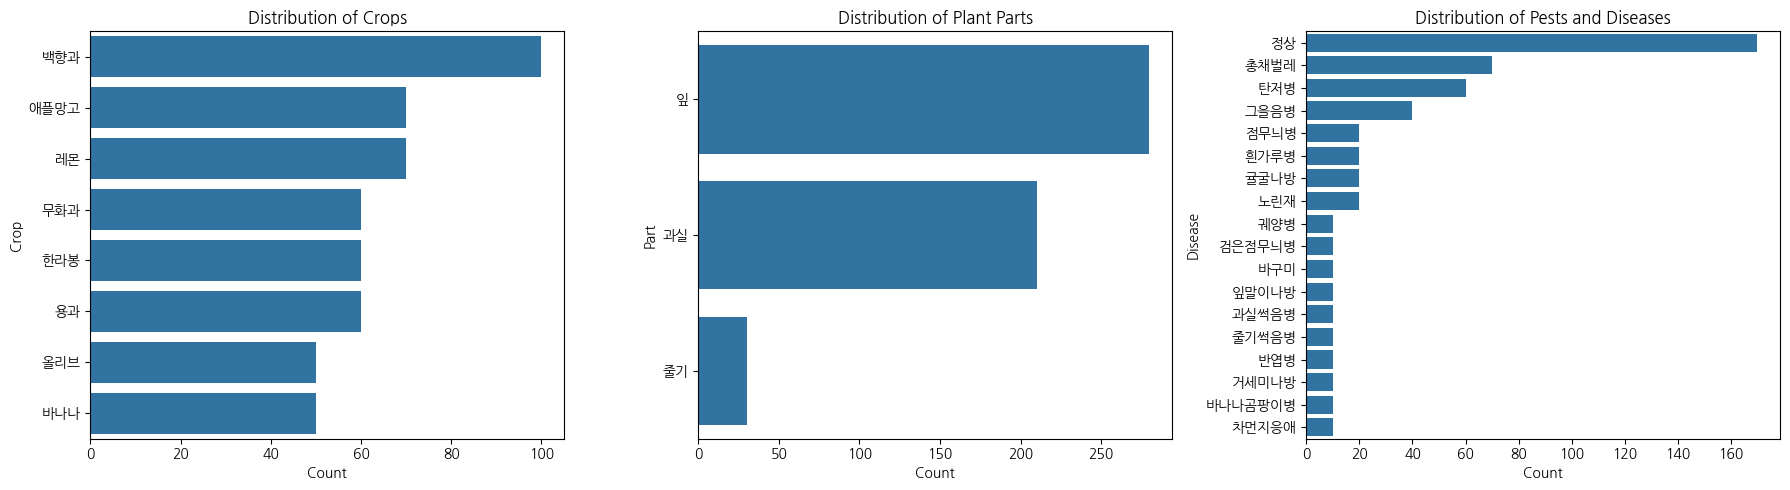

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col, title, ylabel in [
    (axes[0], "crop", "Distribution of Crops", "Crop"),
    (axes[1], "part", "Distribution of Plant Parts", "Part"),
    (axes[2], "disease", "Distribution of Pests and Diseases", "Disease"),
]:
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, order=order, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Count")
    ax.set_ylabel(ylabel)
plt.tight_layout()
plt.show()


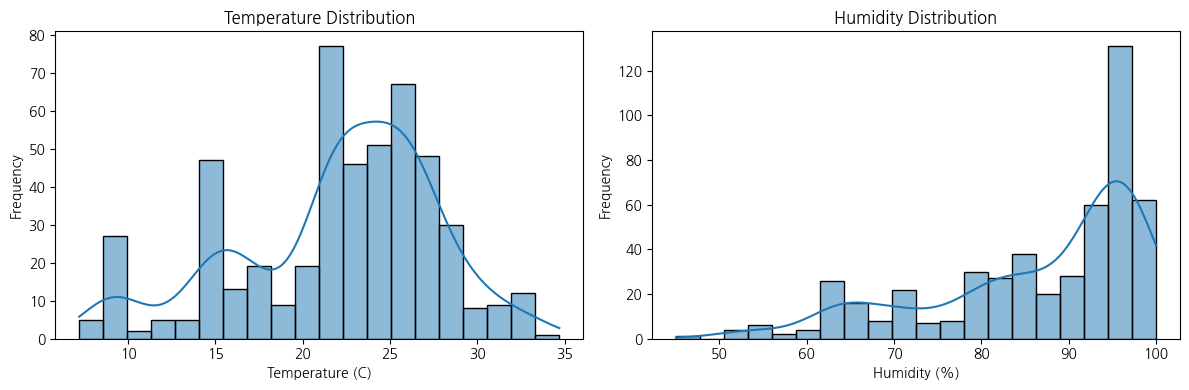

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["temp"].dropna(), kde=True, bins=20, ax=axes[0])
axes[0].set_title("Temperature Distribution")
axes[0].set_xlabel("Temperature (C)")
axes[0].set_ylabel("Frequency")

sns.histplot(df["hum"].dropna(), kde=True, bins=20, ax=axes[1])
axes[1].set_title("Humidity Distribution")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


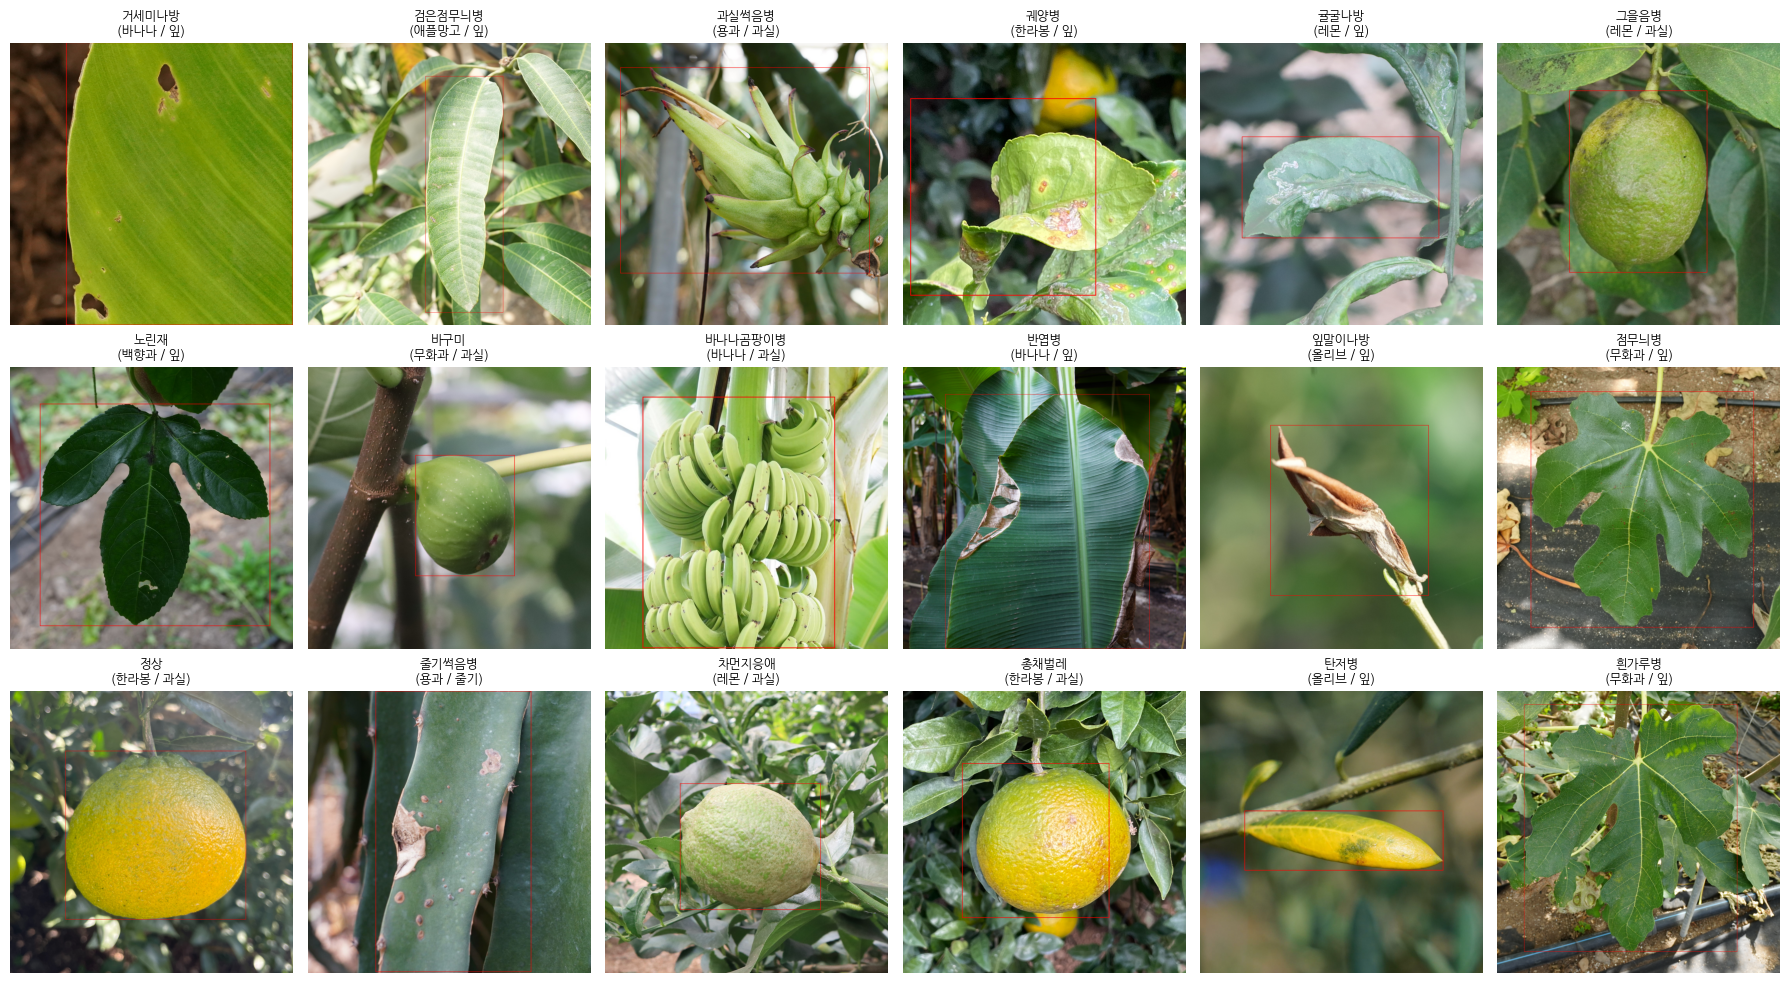

In [7]:
def draw_bboxes(ax, image, bboxes, color="red", width=3):
    if isinstance(image, np.ndarray):
        img = Image.fromarray(image)
    else:
        img = image.copy()
    draw = ImageDraw.Draw(img)
    for b in bboxes or []:
        x, y, w, h = b["x"], b["y"], b["w"], b["h"]
        draw.rectangle([x, y, x + w, y + h], outline=color, width=width)
    ax.imshow(img)
    ax.axis("off")


try:
    samples = df.groupby("disease", group_keys=False).sample(n=1, random_state=0).reset_index(drop=True)
except Exception:
    samples = (
        df.groupby("disease", group_keys=False)
        .apply(lambda g: g.sample(1, random_state=0))
        .reset_index(drop=True)
    )

plt.figure(figsize=(18, 10))
for i, row in samples.iterrows():
    ax = plt.subplot(3, 6, i + 1)
    img = Image.open(row["path"]).convert("RGB")
    draw_bboxes(ax, img, row["bboxes"], color="red")
    ax.set_title(f"{row['disease']}\n({row['crop']} / {row['part']})", fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
counts = df["disease"].value_counts().sort_values(ascending=False)
display(counts.to_frame("count"))

max_cls = counts.index[0]
max_n = int(counts.iloc[0])
min_n = int(counts.min())
min_cls = sorted(counts[counts == min_n].index.tolist())[0]
print(f"최다 클래스: {max_cls} ({max_n})")
print(f"최소 클래스: {min_cls} ({min_n})")


,count
disease,
정상,170
총채벌레,70
탄저병,60
그을음병,40
점무늬병,20
흰가루병,20
귤굴나방,20
노린재,20
궤양병,10


최다 클래스: 정상 (170)
최소 클래스: 거세미나방 (10)


## 문제 5. 전처리

In [9]:
crops = sorted(df["crop"].unique())
crop2id = {c: i for i, c in enumerate(crops)}
id2crop = {i: c for i, c in enumerate(crops)}

parts = sorted(df["part"].unique())
part2id = {p: i for i, p in enumerate(parts)}
id2part = {i: p for i, p in enumerate(parts)}

diseases = sorted(df["disease"].unique())
disease2id = {d: i for i, d in enumerate(diseases)}
id2disease = {i: d for i, d in enumerate(diseases)}

num_crops = len(crops)
num_parts = len(parts)
num_diseases = len(diseases)

print(f"Number of crops: {num_crops}")
print(f"Number of parts: {num_parts}")
print(f"Number of diseases: {num_diseases}")
print(f"작물 클래스: {crops}")
print(f"부위 클래스: {parts}")
print(f"병해충 클래스: {diseases}")

keep_idx, x_norms, y_norms, w_norms, h_norms = [], [], [], [], []
bad = 0
for i, row in df.iterrows():
    try:
        with Image.open(row["path"]) as im:
            W, H = im.size
        if W <= 0 or H <= 0:
            raise ValueError("invalid size")
        keep_idx.append(i)
        x_norms.append(float(np.clip(row["bbox_x"] / W, 0, 1)))
        y_norms.append(float(np.clip(row["bbox_y"] / H, 0, 1)))
        w_norms.append(float(np.clip(row["bbox_w"] / W, 0, 1)))
        h_norms.append(float(np.clip(row["bbox_h"] / H, 0, 1)))
    except Exception:
        bad += 1

print(f"이미지 크기 읽기 실패로 제외: {bad}")
df = df.loc[keep_idx].copy().reset_index(drop=True)
df["x_norm"] = x_norms
df["y_norm"] = y_norms
df["w_norm"] = w_norms
df["h_norm"] = h_norms
df["crop_id"] = df["crop"].map(crop2id)
df["part_id"] = df["part"].map(part2id)
df["disease_id"] = df["disease"].map(disease2id)

train_data, valid_data = train_test_split(
    df, test_size=0.2, stratify=df["disease"], random_state=42
)
train_data = train_data.reset_index(drop=True)
valid_data = valid_data.reset_index(drop=True)
print(f"Train data: {len(train_data)}, Valid data: {len(valid_data)}")


Number of crops: 8
Number of parts: 3
Number of diseases: 18
작물 클래스: ['레몬', '무화과', '바나나', '백향과', '애플망고', '올리브', '용과', '한라봉']
부위 클래스: ['과실', '잎', '줄기']
병해충 클래스: ['거세미나방', '검은점무늬병', '과실썩음병', '궤양병', '귤굴나방', '그을음병', '노린재', '바구미', '바나나곰팡이병', '반엽병', '잎말이나방', '점무늬병', '정상', '줄기썩음병', '차먼지응애', '총채벌레', '탄저병', '흰가루병']
이미지 크기 읽기 실패로 제외: 0
Train data: 416, Valid data: 104


## 문제 6. Dataset / DataLoader

In [10]:
from transformers import AutoImageProcessor

MODEL_NAME = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)


def resolve_image_size(proc, default=224):
    """AutoImageProcessor.size: dict / SizeDict / int 등 버전별 호환."""
    size = getattr(proc, "size", None)
    if size is None:
        return default
    if isinstance(size, (int, float)):
        return int(size)
    if hasattr(size, "get"):
        for key in ("height", "shortest_edge", "width"):
            val = size.get(key)
            if val is not None:
                return int(val)
    for key in ("height", "shortest_edge", "width"):
        if hasattr(size, key):
            val = getattr(size, key)
            if val is not None:
                return int(val)
    try:
        return int(size)
    except (TypeError, ValueError):
        return default


IMAGE_SIZE = resolve_image_size(processor)
print(f"Processor ready: {MODEL_NAME} (image_size={IMAGE_SIZE})")


class PestDataset(Dataset):
    def __init__(self, frame, processor, is_test=False):
        self.paths = frame["path"].tolist()
        self.is_test = is_test
        self.processor = processor
        if not is_test:
            self.crop_ids = frame["crop_id"].astype(int).tolist()
            self.part_ids = frame["part_id"].astype(int).tolist()
            self.disease_ids = frame["disease_id"].astype(int).tolist()
            self.bboxes = frame[["x_norm", "y_norm", "w_norm", "h_norm"]].astype("float32").values

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        pv = self.processor(images=img, return_tensors="pt")["pixel_values"][0]
        if self.is_test:
            return pv
        return (
            pv,
            torch.tensor(self.crop_ids[idx], dtype=torch.long),
            torch.tensor(self.part_ids[idx], dtype=torch.long),
            torch.tensor(self.disease_ids[idx], dtype=torch.long),
            torch.tensor(self.bboxes[idx], dtype=torch.float32),
        )


def auto_batch_size():
    if not torch.cuda.is_available():
        return 4
    vram = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if vram >= 20:
        return 32
    if vram >= 12:
        return 24
    if vram >= 8:
        return 16
    if vram >= 6:
        return 12
    if vram >= 4:
        return 8
    return 4


BATCH_SIZE = auto_batch_size()
NUM_WORKERS = 2 if IN_COLAB else 0

train_ds = PestDataset(train_data, processor, is_test=False)
valid_ds = PestDataset(valid_data, processor, is_test=False)

loader_kwargs = {"num_workers": NUM_WORKERS, "pin_memory": use_cuda}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, **loader_kwargs)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)
print(f"DataLoaders are ready. batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}")


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Processor ready: google/vit-base-patch16-224 (image_size=224)
DataLoaders are ready. batch_size=32, num_workers=2


## 문제 7. 모델 정의

In [11]:
from transformers import ViTModel, ViTConfig


class PestAnalysisModel(nn.Module):
    def __init__(
        self,
        model_name="google/vit-base-patch16-224",
        pretrained=True,
        num_crops=8,
        num_parts=3,
        num_diseases=18,
    ):
        super().__init__()
        self.model_name = model_name
        if pretrained:
            self.backbone = ViTModel.from_pretrained(model_name)
        else:
            self.backbone = ViTModel(ViTConfig.from_pretrained(model_name))
        hidden = self.backbone.config.hidden_size
        self.fc_crop = nn.Linear(hidden, num_crops)
        self.fc_part = nn.Linear(hidden, num_parts)
        self.fc_disease = nn.Linear(hidden, num_diseases)
        self.fc_bbox = nn.Linear(hidden, 4)

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        if getattr(outputs, "pooler_output", None) is not None:
            feat = outputs.pooler_output
        else:
            feat = outputs.last_hidden_state[:, 0]
        out_c = self.fc_crop(feat)
        out_p = self.fc_part(feat)
        out_d = self.fc_disease(feat)
        out_b = torch.sigmoid(self.fc_bbox(feat))
        return out_c, out_p, out_d, out_b


print("Model class is ready")
_tmp = PestAnalysisModel(pretrained=False)
print(f"Backbone: {_tmp.model_name} (hidden_size={_tmp.backbone.config.hidden_size})")
del _tmp


Model class is ready
Backbone: google/vit-base-patch16-224 (hidden_size=768)


## 문제 8. 학습

In [12]:
WEIGHT_C = 0.30
WEIGHT_P = 0.20
WEIGHT_B = 0.10
EPOCHS = 8
CKPT_PATH = "best_model.pth"

model = PestAnalysisModel(
    model_name=MODEL_NAME,
    pretrained=True,
    num_crops=num_crops,
    num_parts=num_parts,
    num_diseases=num_diseases,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
ce = nn.CrossEntropyLoss()
l1 = nn.SmoothL1Loss()

from torch.amp import GradScaler, autocast
scaler = GradScaler("cuda", enabled=use_cuda)

print(
    f"Start Training for {EPOCHS} epochs... "
    f"(AMP={use_cuda}, batch_size={BATCH_SIZE}, backbone={MODEL_NAME})"
)

best_acc = -1.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss, n_batches = 0.0, 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for step, (pv, y_c, y_p, y_d, y_b) in enumerate(pbar, start=1):
        pv = pv.to(device, non_blocking=True)
        y_c = y_c.to(device, non_blocking=True)
        y_p = y_p.to(device, non_blocking=True)
        y_d = y_d.to(device, non_blocking=True)
        y_b = y_b.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with autocast("cuda", enabled=use_cuda):
            out_c, out_p, out_d, out_b = model(pv)
            loss_c = ce(out_c, y_c)
            loss_p = ce(out_p, y_p)
            loss_d = ce(out_d, y_d)
            loss_b = l1(out_b.float(), y_b.float())
            loss = loss_d + WEIGHT_C * loss_c + WEIGHT_P * loss_p + WEIGHT_B * loss_b

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        n_batches += 1
        if step % 20 == 0:
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    train_loss = running_loss / max(n_batches, 1)

    model.eval()
    correct_d = correct_c = correct_p = total = 0
    with torch.inference_mode():
        for pv, y_c, y_p, y_d, y_b in valid_loader:
            pv = pv.to(device, non_blocking=True)
            y_c = y_c.to(device, non_blocking=True)
            y_p = y_p.to(device, non_blocking=True)
            y_d = y_d.to(device, non_blocking=True)
            with autocast("cuda", enabled=use_cuda):
                out_c, out_p, out_d, out_b = model(pv)
            total += y_d.size(0)
            correct_d += (out_d.argmax(dim=1) == y_d).sum().item()
            correct_c += (out_c.argmax(dim=1) == y_c).sum().item()
            correct_p += (out_p.argmax(dim=1) == y_p).sum().item()

    valid_acc = correct_d / max(total, 1)
    crop_acc = correct_c / max(total, 1)
    part_acc = correct_p / max(total, 1)

    print(f"Epoch {epoch} Result:")
    print(f"  Train Loss : {train_loss:.4f}")
    print(f"  Valid Acc  : {valid_acc:.4f} ({valid_acc * 100:.2f}%)")
    print(f"  Crop Acc   : {crop_acc:.4f} ({crop_acc * 100:.2f}%)")
    print(f"  Part Acc   : {part_acc:.4f} ({part_acc * 100:.2f}%)")

    if valid_acc > best_acc:
        print(
            f"  [Create Best Model] Accuracy improved from {best_acc:.4f} to {valid_acc:.4f}. Saving model..."
        )
        best_acc = valid_acc
        torch.save(
            {
                "model": model.state_dict(),
                "model_name": MODEL_NAME,
                "id2crop": id2crop,
                "id2part": id2part,
                "id2disease": id2disease,
                "num_crops": num_crops,
                "num_parts": num_parts,
                "num_diseases": num_diseases,
                "image_size": IMAGE_SIZE,
            },
            CKPT_PATH,
        )
    else:
        print(f"  Accuracy did not improve from {best_acc:.4f}")

print("Training Finished.")
print(f"Best Validation Accuracy: {best_acc:.4f}")

# RTX 3060 12G 약 6분 소요
# Colab A100 약 2분 소요

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Start Training for 8 epochs... (AMP=True, batch_size=32, backbone=google/vit-base-patch16-224)


...

Epoch 6 Result:
  Train Loss : 1.6210
  Valid Acc  : 0.4904 (49.04%)
  Crop Acc   : 0.8846 (88.46%)
  Part Acc   : 0.9519 (95.19%)
  [Create Best Model] Accuracy improved from 0.4231 to 0.4904. Saving model...


Epoch 7/8:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 7 Result:
  Train Loss : 1.3633
  Valid Acc  : 0.5192 (51.92%)
  Crop Acc   : 0.9038 (90.38%)
  Part Acc   : 0.9712 (97.12%)
  [Create Best Model] Accuracy improved from 0.4904 to 0.5192. Saving model...


Epoch 8/8:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 8 Result:
  Train Loss : 1.1359
  Valid Acc  : 0.5673 (56.73%)
  Crop Acc   : 0.9135 (91.35%)
  Part Acc   : 0.9712 (97.12%)
  [Create Best Model] Accuracy improved from 0.5192 to 0.5673. Saving model...
Training Finished.
Best Validation Accuracy: 0.5673


## 문제 9. 혼동 행렬과 오분류 확인

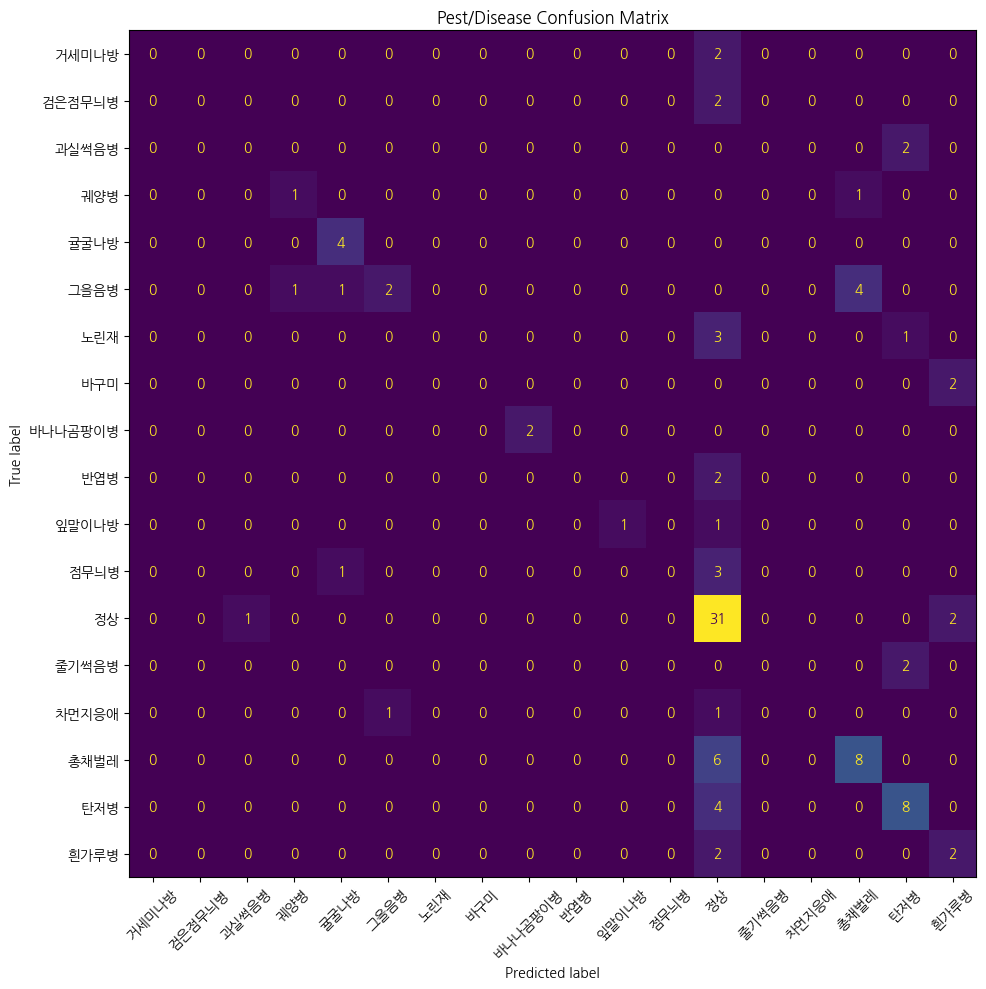

취약 클래스 Top-3
  - 거세미나방   acc=0.0%   support=2
  - 검은점무늬병   acc=0.0%   support=2
  - 과실썩음병   acc=0.0%   support=2


In [13]:
assert os.path.isfile(CKPT_PATH), "best_model.pth가 없습니다. 먼저 학습 셀을 실행하세요."
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)

eval_model = PestAnalysisModel(
    model_name=ckpt["model_name"],
    pretrained=False,
    num_crops=ckpt["num_crops"],
    num_parts=ckpt["num_parts"],
    num_diseases=ckpt["num_diseases"],
).to(device)
eval_model.load_state_dict(ckpt["model"])
eval_model.eval()

id2disease = ckpt["id2disease"]
y_true, y_pred = [], []
with torch.inference_mode():
    for pv, y_c, y_p, y_d, y_b in valid_loader:
        pv = pv.to(device, non_blocking=True)
        with autocast("cuda", enabled=use_cuda):
            _, _, out_d, _ = eval_model(pv)
        y_pred.extend(out_d.argmax(dim=1).cpu().tolist())
        y_true.extend(y_d.tolist())

labels = list(range(len(id2disease)))
label_names = [id2disease[i] for i in labels]
cm = confusion_matrix(y_true, y_pred, labels=labels)
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names).plot(
    ax=ax, xticks_rotation=45, colorbar=False
)
ax.set_title("Pest/Disease Confusion Matrix")
plt.tight_layout()
plt.show()

print("취약 클래스 Top-3")
cls_stats = []
for i, name in id2disease.items():
    support = sum(yt == i for yt in y_true)
    if support == 0:
        acc = 0.0
    else:
        acc = sum(1 for yt, yp in zip(y_true, y_pred) if yt == i and yt == yp) / support
    cls_stats.append((name, acc, support))
cls_stats.sort(key=lambda x: (x[1], x[0]))
for name, acc, support in cls_stats[:3]:
    print(f"  - {name}   acc={acc * 100:.1f}%   support={support}")


## 문제 10. 이미지 업로드 후 예측

- **Colab**: `files.upload()` 로 이미지 선택
- **로컬**: `./uploaded_images` 폴더의 이미지를 사용합니다. 비어 있으면 검증셋 샘플 1장을 복사해 데모합니다.


Saving HF002_02_015_00010.JPG to HF002_02_015_00010.JPG


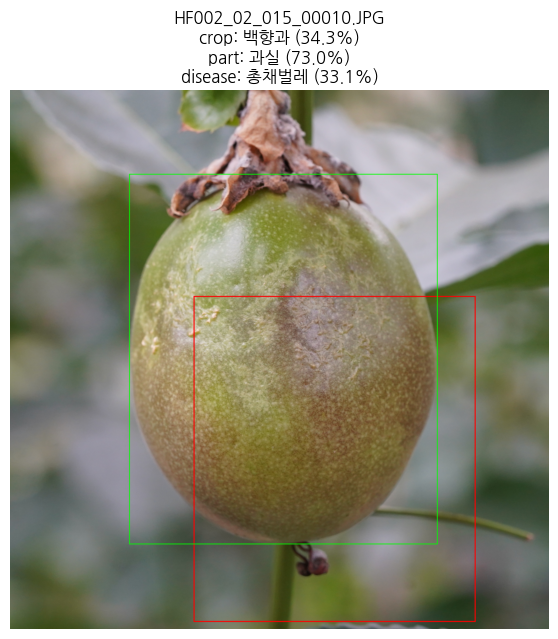

파일: HF002_02_015_00010.JPG
작물 Top-3
  - 백향과                             34.3%
  - 레몬                              15.1%
  - 애플망고                            14.4%
부위 Top-3
  - 과실                              73.0%
  - 잎                               20.0%
  - 줄기                               7.0%
병해충 Top-3
  - 총채벌레                            33.1%
  - 정상                              31.2%
  - 탄저병                              6.7%
bbox(pixel): x=681.2, y=764.2, w=1045.9, h=1209.0
GT: 백향과 / 과실 / 총채벌레
----------------------------------------


In [14]:
CKPT_PATH = "best_model.pth"
if not os.path.isfile(CKPT_PATH):
    raise FileNotFoundError("best_model.pth가 없습니다. 먼저 학습 셀을 실행하세요.")

ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
pred_processor = AutoImageProcessor.from_pretrained(ckpt["model_name"])
pred_model = PestAnalysisModel(
    model_name=ckpt["model_name"],
    pretrained=False,
    num_crops=ckpt["num_crops"],
    num_parts=ckpt["num_parts"],
    num_diseases=ckpt["num_diseases"],
).to(device)
pred_model.load_state_dict(ckpt["model"])
pred_model.eval()

id2crop = ckpt["id2crop"]
id2part = ckpt["id2part"]
id2disease = ckpt["id2disease"]

UPLOAD_DIR = "/content/uploaded_images" if IN_COLAB else "./uploaded_images"
os.makedirs(UPLOAD_DIR, exist_ok=True)

gt_by_name = {str(r.image_file_nm): r for r in df.itertuples()}
gt_by_name_lower = {k.lower(): v for k, v in gt_by_name.items()}


def _top3(logits, id2name):
    prob = torch.softmax(logits, dim=-1)[0]
    vals, idxs = torch.topk(prob, k=min(3, prob.numel()))
    return [(id2name[int(i)], float(v) * 100.0) for v, i in zip(vals, idxs)]


def predict_one(image_path, model, processor, device):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size
    pv = processor(images=img, return_tensors="pt")["pixel_values"].to(device)
    with torch.inference_mode():
        with autocast("cuda", enabled=use_cuda):
            out_c, out_p, out_d, out_b = model(pv)
    crop_top = _top3(out_c, id2crop)
    part_top = _top3(out_p, id2part)
    disease_top = _top3(out_d, id2disease)
    x, y, w, h = out_b[0].float().cpu().tolist()
    bbox_pix = {"x": x * W, "y": y * H, "w": w * W, "h": h * H}
    return img, crop_top, part_top, disease_top, bbox_pix


image_paths = []
if IN_COLAB:
    uploaded = files.upload()
    for name, data in uploaded.items():
        if Path(name).suffix.lower() in {".jpg", ".jpeg", ".png"}:
            out = Path(UPLOAD_DIR) / name
            with open(out, "wb") as f:
                f.write(data)
            image_paths.append(str(out))
else:
    for ext in ("*.jpg", "*.JPG", "*.jpeg", "*.JPEG", "*.png", "*.PNG"):
        image_paths.extend([str(p) for p in Path(UPLOAD_DIR).glob(ext)])
    if not image_paths:
        demo_src = valid_data.iloc[0]["path"]
        demo_name = valid_data.iloc[0]["image_file_nm"]
        demo_dst = Path(UPLOAD_DIR) / demo_name
        Image.open(demo_src).save(demo_dst)
        image_paths = [str(demo_dst)]
        print(f"로컬 uploaded_images가 비어 있어 검증 샘플을 복사했습니다: {demo_name}")

if not image_paths:
    raise FileNotFoundError("예측할 이미지가 없습니다.")

for img_path in image_paths:
    fname = Path(img_path).name
    img, crop_top, part_top, disease_top, bbox_pix = predict_one(
        img_path, pred_model, pred_processor, device
    )

    vis = img.copy()
    draw = ImageDraw.Draw(vis)
    px, py, pw, ph = bbox_pix["x"], bbox_pix["y"], bbox_pix["w"], bbox_pix["h"]
    draw.rectangle([px, py, px + pw, py + ph], outline="red", width=4)

    gt_row = gt_by_name.get(fname) or gt_by_name_lower.get(fname.lower())
    gt_line = None
    if gt_row is not None:
        for b in gt_row.bboxes:
            draw.rectangle(
                [b["x"], b["y"], b["x"] + b["w"], b["y"] + b["h"]],
                outline="lime",
                width=3,
            )
        gt_line = f"GT: {gt_row.crop} / {gt_row.part} / {gt_row.disease}"

    title = (
        f"{fname}\n"
        f"crop: {crop_top[0][0]} ({crop_top[0][1]:.1f}%)\n"
        f"part: {part_top[0][0]} ({part_top[0][1]:.1f}%)\n"
        f"disease: {disease_top[0][0]} ({disease_top[0][1]:.1f}%)"
    )
    plt.figure(figsize=(7, 7))
    plt.imshow(vis)
    plt.title(title)
    plt.axis("off")
    plt.show()

    print(f"파일: {fname}")
    print("작물 Top-3")
    for name, p in crop_top:
        print(f"  - {name:<30} {p:5.1f}%")
    print("부위 Top-3")
    for name, p in part_top:
        print(f"  - {name:<30} {p:5.1f}%")
    print("병해충 Top-3")
    for name, p in disease_top:
        print(f"  - {name:<30} {p:5.1f}%")
    print(
        f"bbox(pixel): x={bbox_pix['x']:.1f}, y={bbox_pix['y']:.1f}, "
        f"w={bbox_pix['w']:.1f}, h={bbox_pix['h']:.1f}"
    )
    if gt_line:
        print(gt_line)
    print("-" * 40)
